<a href="https://colab.research.google.com/github/Chandana-dharshanam/ecg-detection/blob/main/ecg-detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wfdb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 20.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.


In [ ]:
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("WFDB Version:", wfdb.__version__)
print("Pandas Version:", pd.__version__)

WFDB Version: 4.3.1
Pandas Version: 3.0.5


In [ ]:
import wfdb

record = wfdb.rdrecord('100', pn_dir='mitdb')

print(record.record_name)

100


In [ ]:
print(type(record))


<class 'wfdb.io.record.Record'>


In [ ]:
dir(record)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adjust_datetime',
 '_arrange_fields',
 '_auto_signal_file_names',
 'adc',
 'adc_gain',
 'adc_res',
 'adc_zero',
 'base_counter',
 'base_date',
 'base_datetime',
 'base_time',
 'baseline',
 'block_size',
 'byte_offset',
 'calc_adc_gain_baseline',
 'calc_adc_params',
 'calc_checksum',
 'check_field',
 'check_field_cohesion',
 'check_read_inputs',
 'check_sig_cohesion',
 'checksum',
 'comments',
 'convert_dtype',
 'counter_freq',
 'd_signal',
 'dac',
 'e_d_signal',
 'e_p_signal',
 'file_name',
 'fmt',
 'fs',
 'get_absolute_time',
 'get_elapsed_time',
 'get_frame_number',
 'get_write_fields',
 'get_write_su

In [ ]:
print(record.record_name)


100


In [ ]:
#sampling frequency
print(record.fs)


360


In [ ]:
#ECG leads
print(record.sig_name)


['MLII', 'V5']


In [ ]:
#measures of ecg signals
print(record.units)


['mV', 'mV']


In [ ]:
#(measuements,ecg leads)
print(record.p_signal.shape)

(650000, 2)


In [ ]:
ecg = record.p_signal[:,0]
print(type(ecg))

<class 'numpy.ndarray'>


In [ ]:
print(ecg.shape)

(650000,)


In [ ]:
print(ecg[:10])

[-0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.145 -0.12  -0.135]


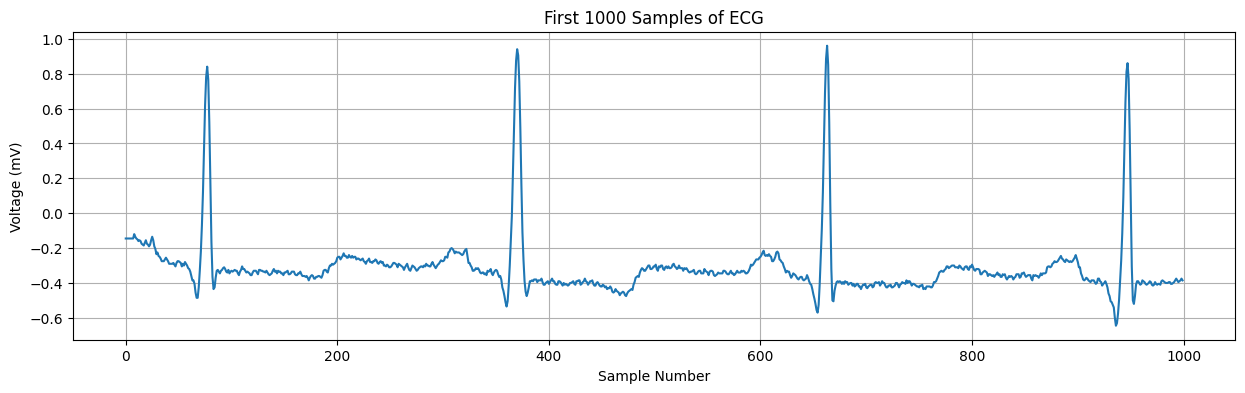

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.plot(ecg[:1000])

plt.title("First 1000 Samples of ECG")

plt.xlabel("Sample Number")

plt.ylabel("Voltage (mV)")

plt.grid(True)

plt.show()

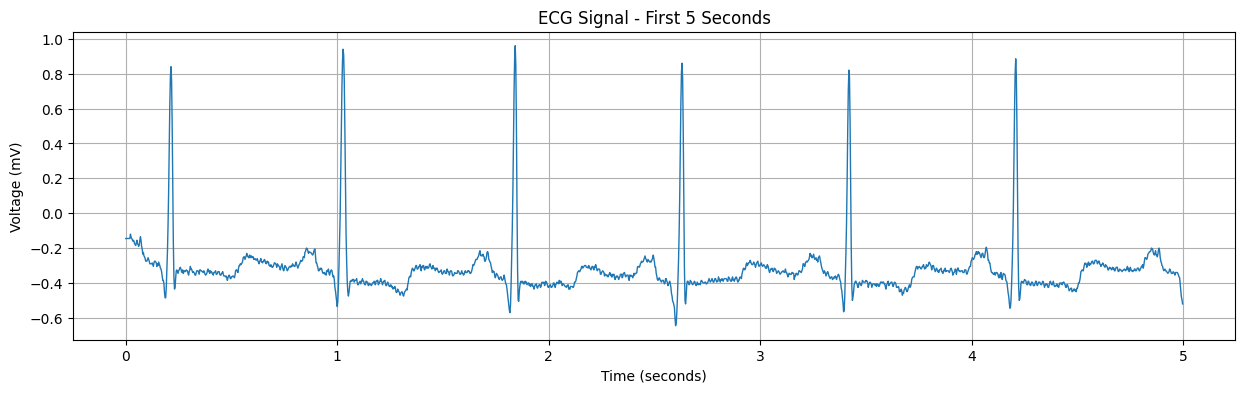

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract MLII lead
ecg = record.p_signal[:, 0]

# Create time axis
time = np.arange(len(ecg)) / record.fs

# Plot first 5 seconds
duration = 5  # seconds
samples = int(duration * record.fs)

plt.figure(figsize=(15,4))
plt.plot(time[:samples], ecg[:samples], linewidth=1)

plt.title(f"ECG Signal - First {duration} Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

In [ ]:
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')
print(type(annotation))

<class 'wfdb.io.annotation.Annotation'>


In [ ]:
print(annotation.sample[:20])

[  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]


In [ ]:
print(annotation.symbol[:20])

['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [ ]:
print(len(annotation.sample))

2274


In [ ]:
print(len(annotation.symbol))

2274


In [ ]:
#time=sample/360
for sample, symbol in zip(annotation.sample[:20], annotation.symbol[:20]):
    print(sample, symbol)

18 +
77 N
370 N
662 N
946 N
1231 N
1515 N
1809 N
2044 A
2402 N
2706 N
2998 N
3282 N
3560 N
3862 N
4170 N
4466 N
4764 N
5060 N
5346 N


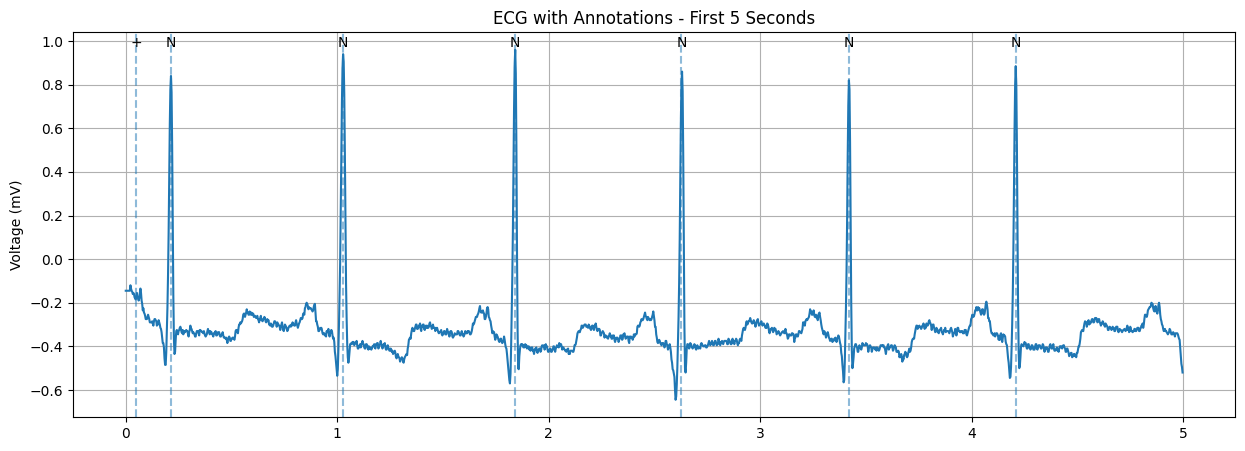

In [ ]:
import matplotlib.pyplot as plt

# First 5 seconds
duration = 5
samples = int(duration * record.fs)

# Get annotations that occur within the first 5 seconds
mask = annotation.sample < samples

ann_samples = annotation.sample[mask]
ann_symbols = np.array(annotation.symbol)[mask]

# Convert annotation sample numbers to time
ann_times = ann_samples / record.fs

# Plot ECG
plt.figure(figsize=(15, 5))
plt.plot(time[:samples], ecg[:samples])

# Mark annotations
for t, symbol in zip(ann_times, ann_symbols):
    plt.axvline(t, linestyle='--', alpha=0.5)
    plt.text(t, max(ecg[:samples]), symbol,
             ha='center', va='bottom')

plt.title("ECG with Annotations - First 5 Seconds")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

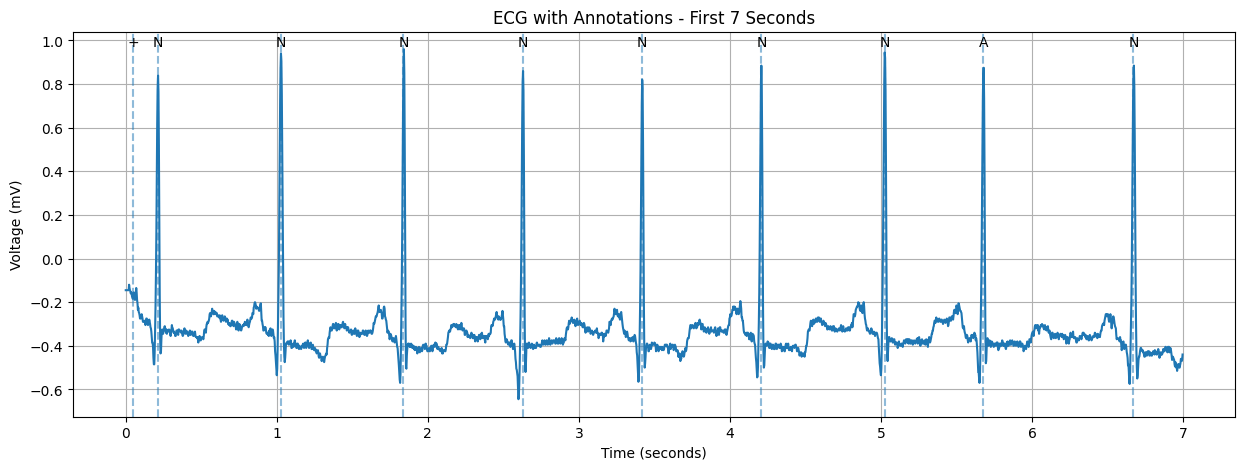

In [ ]:
duration = 7
samples = int(duration * record.fs)

mask = annotation.sample < samples

ann_samples = annotation.sample[mask]
ann_symbols = np.array(annotation.symbol)[mask]

ann_times = ann_samples / record.fs

plt.figure(figsize=(15, 5))
plt.plot(time[:samples], ecg[:samples])

for t, symbol in zip(ann_times, ann_symbols):
    plt.axvline(t, linestyle='--', alpha=0.5)
    plt.text(t, max(ecg[:samples]), symbol,
             ha='center', va='bottom')

plt.title("ECG with Annotations - First 7 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

In [ ]:
#Band pass Filter
from scipy.signal import butter, filtfilt

# Sampling frequency
fs = record.fs

# Filter settings
low_cutoff = 0.5
high_cutoff = 40

# Create a 4th-order Butterworth band-pass filter
b, a = butter(
    4,
    [low_cutoff, high_cutoff],
    btype='bandpass',
    fs=fs
)

# Apply the filter
ecg_filtered = filtfilt(b, a, ecg)

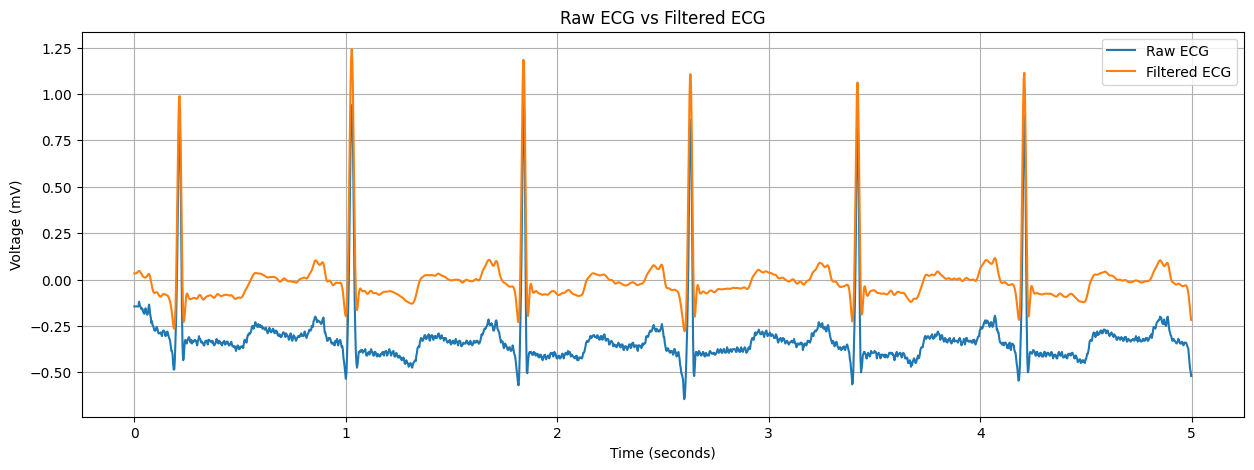

In [ ]:
duration = 5
samples = int(duration * fs)

plt.figure(figsize=(15, 5))

plt.plot(time[:samples], ecg[:samples], label="Raw ECG")
plt.plot(time[:samples], ecg_filtered[:samples], label="Filtered ECG")

plt.title("Raw ECG vs Filtered ECG")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

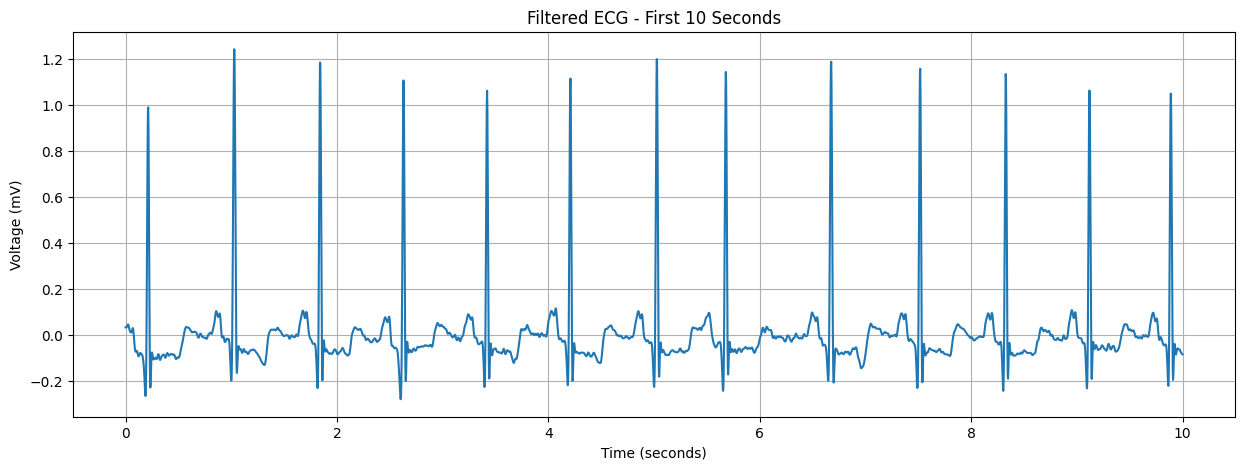

In [ ]:
duration = 10
samples = int(duration * fs)

plt.figure(figsize=(15, 5))

plt.plot(time[:samples], ecg_filtered[:samples])

plt.title("Filtered ECG - First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.grid(True)

plt.show()

In [ ]:
from scipy.signal import find_peaks

r_peaks, properties = find_peaks(
    ecg_filtered,
    distance=int(0.25 * fs),
    prominence=0.5
)

print("Number of detected R-peaks:", len(r_peaks))
print("First 20 detected R-peaks:", r_peaks[:20])

Number of detected R-peaks: 2273
First 20 detected R-peaks: [  77  370  662  947 1231 1515 1809 2044 2403 2706 2997 3282 3559 3862
 4170 4466 4764 5060 5346 5634]


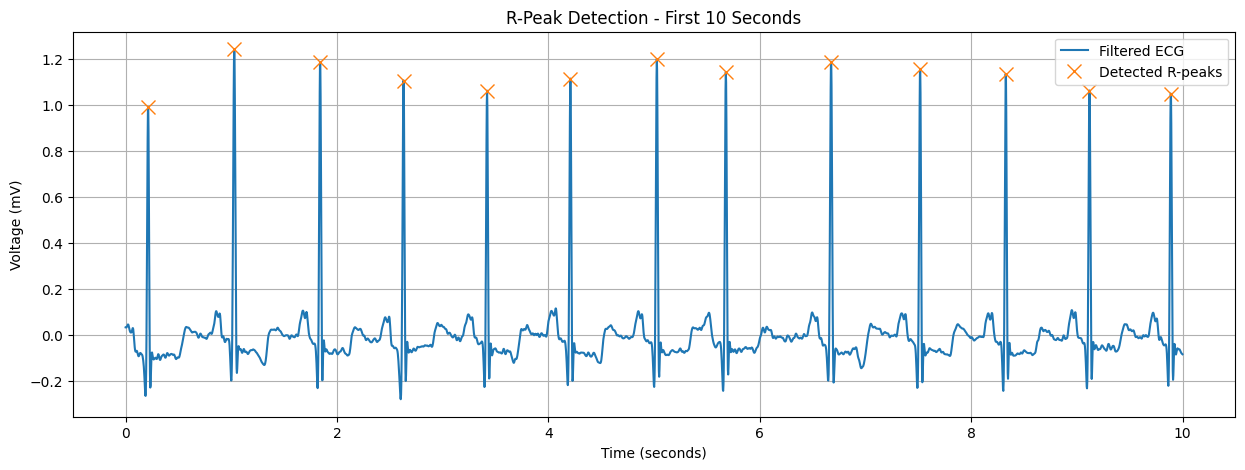

In [ ]:
#R-peak Detection
duration = 10
samples = int(duration * fs)

# Only peaks within the first 10 seconds
peaks_10s = r_peaks[r_peaks < samples]

plt.figure(figsize=(15, 5))

plt.plot(
    time[:samples],
    ecg_filtered[:samples],
    label="Filtered ECG"
)

plt.plot(
    time[peaks_10s],
    ecg_filtered[peaks_10s],
    'x',
    markersize=10,
    label="Detected R-peaks"
)

plt.title("R-Peak Detection - First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
r_peak_times = r_peaks / fs

print("First 20 R-peak times:")
print(r_peak_times[:20])

First 20 R-peak times:
[ 0.21388889  1.02777778  1.83888889  2.63055556  3.41944444  4.20833333
  5.025       5.67777778  6.675       7.51666667  8.325       9.11666667
  9.88611111 10.72777778 11.58333333 12.40555556 13.23333333 14.05555556
 14.85       15.65      ]


In [ ]:
#Expert annotations vs our detected R-peaks.
# Expert annotation samples in first 10 seconds
annotation_samples_10s = annotation.sample[
    annotation.sample < int(10 * fs)
]

annotation_symbols_10s = np.array(annotation.symbol)[
    annotation.sample < int(10 * fs)
]

print("Expert annotations:")
for sample, symbol in zip(annotation_samples_10s, annotation_symbols_10s):
    print(f"Sample: {sample:4d} | Time: {sample/fs:.4f} s | Label: {symbol}")

Expert annotations:
Sample:   18 | Time: 0.0500 s | Label: +
Sample:   77 | Time: 0.2139 s | Label: N
Sample:  370 | Time: 1.0278 s | Label: N
Sample:  662 | Time: 1.8389 s | Label: N
Sample:  946 | Time: 2.6278 s | Label: N
Sample: 1231 | Time: 3.4194 s | Label: N
Sample: 1515 | Time: 4.2083 s | Label: N
Sample: 1809 | Time: 5.0250 s | Label: N
Sample: 2044 | Time: 5.6778 s | Label: A
Sample: 2402 | Time: 6.6722 s | Label: N
Sample: 2706 | Time: 7.5167 s | Label: N
Sample: 2998 | Time: 8.3278 s | Label: N
Sample: 3282 | Time: 9.1167 s | Label: N
Sample: 3560 | Time: 9.8889 s | Label: N


In [ ]:
print("\nDetected R-peaks:")
for peak in r_peaks[r_peaks < int(10 * fs)]:
    print(f"Sample: {peak:4d} | Time: {peak/fs:.4f} s")


Detected R-peaks:
Sample:   77 | Time: 0.2139 s
Sample:  370 | Time: 1.0278 s
Sample:  662 | Time: 1.8389 s
Sample:  947 | Time: 2.6306 s
Sample: 1231 | Time: 3.4194 s
Sample: 1515 | Time: 4.2083 s
Sample: 1809 | Time: 5.0250 s
Sample: 2044 | Time: 5.6778 s
Sample: 2403 | Time: 6.6750 s
Sample: 2706 | Time: 7.5167 s
Sample: 2997 | Time: 8.3250 s
Sample: 3282 | Time: 9.1167 s
Sample: 3559 | Time: 9.8861 s


In [ ]:
# Choose the first detected R-peak
peak = r_peaks[0]

# Number of samples before and after R-peak
before = int(0.2 * fs)
after = int(0.4 * fs)

# Extract the beat
beat = ecg_filtered[peak - before : peak + after]

print("R-peak sample:", peak)
print("Beat length:", len(beat))

R-peak sample: 77
Beat length: 216


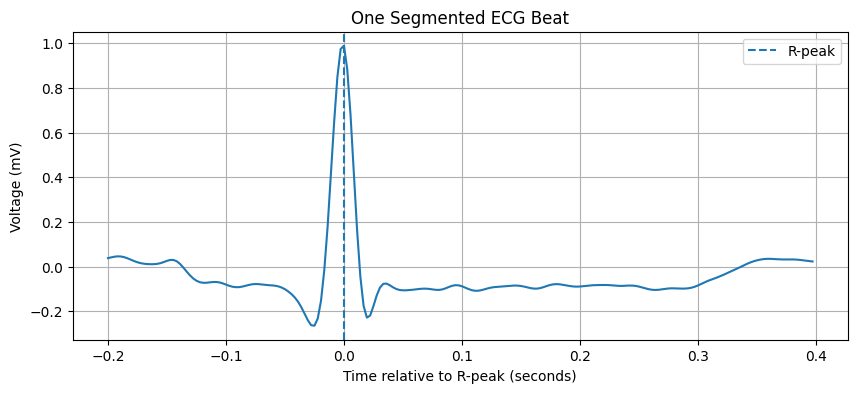

In [ ]:
#Individual Heartbeat
beat_time = np.arange(len(beat)) / fs - 0.2

plt.figure(figsize=(10, 4))

plt.plot(beat_time, beat)

plt.axvline(0, linestyle='--', label='R-peak')

plt.title("One Segmented ECG Beat")
plt.xlabel("Time relative to R-peak (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#All detected R-peaks
beats = []
beat_peak_positions = []

for peak in r_peaks:

    start = peak - before
    end = peak + after

    # Skip peaks too close to the beginning/end
    if start < 0 or end > len(ecg_filtered):
        continue

    beat = ecg_filtered[start:end]

    beats.append(beat)
    beat_peak_positions.append(peak)

beats = np.array(beats)
beat_peak_positions = np.array(beat_peak_positions)

print("Number of segmented beats:", len(beats))
print("Shape of beats array:", beats.shape)

Number of segmented beats: 2272
Shape of beats array: (2272, 216)


**Matching Detected peak and expert Annotation**


In [ ]:
peak = r_peaks[0]

before = int(0.2 * fs)
after = int(0.4 * fs)

beat = ecg_filtered[peak - before : peak + after]

print("R-peak sample:", peak)
print("Beat length:", len(beat))

R-peak sample: 77
Beat length: 216


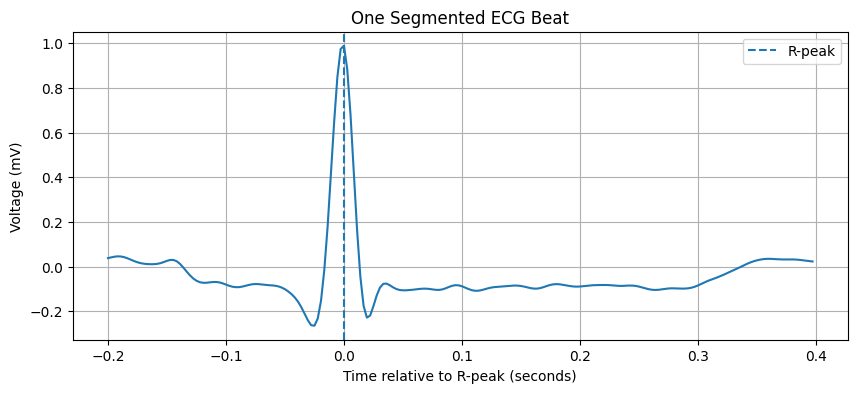

In [ ]:
beat_time = np.arange(len(beat)) / fs - 0.2

plt.figure(figsize=(10, 4))

plt.plot(beat_time, beat)

plt.axvline(0, linestyle='--', label='R-peak')

plt.title("One Segmented ECG Beat")
plt.xlabel("Time relative to R-peak (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

**One beat -> All beats**

In [ ]:
beats = []
beat_peak_positions = []

for peak in r_peaks:

    start = peak - before
    end = peak + after

    # Skip peaks too close to beginning/end
    if start < 0 or end > len(ecg_filtered):
        continue

    beat = ecg_filtered[start:end]

    beats.append(beat)
    beat_peak_positions.append(peak)

beats = np.array(beats)
beat_peak_positions = np.array(beat_peak_positions)

print("Number of segmented beats:", len(beats))
print("Shape of beats array:", beats.shape)

Number of segmented beats: 2272
Shape of beats array: (2272, 216)


**Filtered Annotations**

In [ ]:
# Keep only the beat labels we currently want
valid_labels = ['N', 'A']

filtered_samples = []
filtered_symbols = []

for sample, symbol in zip(annotation.sample, annotation.symbol):
    if symbol in valid_labels:
        filtered_samples.append(sample)
        filtered_symbols.append(symbol)

filtered_samples = np.array(filtered_samples)
filtered_symbols = np.array(filtered_symbols)

print("Number of valid beat annotations:", len(filtered_samples))
print("First 20 samples:", filtered_samples[:20])
print("First 20 labels:", filtered_symbols[:20])

Number of valid beat annotations: 2272
First 20 samples: [  77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560 3862
 4170 4466 4764 5060 5346 5633]
First 20 labels: ['N' 'N' 'N' 'N' 'N' 'N' 'N' 'A' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N' 'N'
 'N' 'N']


In [ ]:
from collections import Counter

beat_labels = [
    symbol for symbol in annotation.symbol
    if symbol in ['N', 'A']
]

print(Counter(beat_labels))

Counter({'N': 2239, 'A': 33})


In [ ]:
print(np.unique(filtered_symbols))

['A' 'N']


In [ ]:
from collections import Counter

print(Counter(filtered_symbols))

Counter({np.str_('N'): 2239, np.str_('A'): 33})


**Match detected beats to expert labels**
**(Beat Labelling)**

In [ ]:
tolerance = int(0.05 * fs)

matched_labels = []
matched_peaks = []

for peak in beat_peak_positions:

    # Find closest expert annotation
    distances = np.abs(filtered_samples - peak)
    closest_index = np.argmin(distances)

    # Check whether it is close enough
    if distances[closest_index] <= tolerance:
        matched_peaks.append(peak)
        matched_labels.append(filtered_symbols[closest_index])

matched_labels = np.array(matched_labels)
matched_peaks = np.array(matched_peaks)

print("Matched beats:", len(matched_labels))
print("Matched label counts:", Counter(matched_labels))

Matched beats: 2271
Matched label counts: Counter({np.str_('N'): 2238, np.str_('A'): 33})


In [ ]:
print("A beats:")

for peak, label in zip(matched_peaks, matched_labels):
    if label == 'A':
        print(
            f"Peak sample: {peak}, "
            f"Time: {peak/fs:.4f} s"
        )

A beats:
Peak sample: 2044, Time: 5.6778 s
Peak sample: 66792, Time: 185.5333 s
Peak sample: 74986, Time: 208.2944 s
Peak sample: 99579, Time: 276.6083 s
Peak sample: 128085, Time: 355.7917 s
Peak sample: 170719, Time: 474.2194 s
Peak sample: 279576, Time: 776.6000 s
Peak sample: 305709, Time: 849.1917 s
Peak sample: 307745, Time: 854.8472 s
Peak sample: 312826, Time: 868.9611 s
Peak sample: 317785, Time: 882.7361 s
Peak sample: 319223, Time: 886.7306 s
Peak sample: 346804, Time: 963.3444 s
Peak sample: 351481, Time: 976.3361 s
Peak sample: 377081, Time: 1047.4472 s
Peak sample: 397336, Time: 1103.7111 s
Peak sample: 421994, Time: 1172.2056 s
Peak sample: 422818, Time: 1174.4944 s
Peak sample: 433841, Time: 1205.1139 s
Peak sample: 436149, Time: 1211.5250 s
Peak sample: 442623, Time: 1229.5083 s
Peak sample: 444705, Time: 1235.2917 s
Peak sample: 454651, Time: 1262.9194 s
Peak sample: 458168, Time: 1272.6889 s
Peak sample: 496713, Time: 1379.7583 s
Peak sample: 520982, Time: 1447.1722 

In [ ]:
unmatched_peaks = []

for peak in beat_peak_positions:
    distances = np.abs(filtered_samples - peak)
    closest_index = np.argmin(distances)

    if distances[closest_index] > tolerance:
        unmatched_peaks.append(
            (peak, distances[closest_index], filtered_samples[closest_index])
        )

print("Number of unmatched peaks:", len(unmatched_peaks))

for peak, distance, closest_annotation in unmatched_peaks:
    print(
        f"Detected peak: {peak} | "
        f"Time: {peak/fs:.4f} s | "
        f"Distance: {distance} samples | "
        f"Closest expert annotation: {closest_annotation}"
    )

Number of unmatched peaks: 1
Detected peak: 546888 | Time: 1519.1333 s | Distance: 289 samples | Closest expert annotation: 546599


In [ ]:
print("Matched A beats:")

for peak, label in zip(matched_peaks, matched_labels):
    if label == 'A':
        print(f"Sample: {peak} | Time: {peak/fs:.4f} s")

Matched A beats:
Sample: 2044 | Time: 5.6778 s
Sample: 66792 | Time: 185.5333 s
Sample: 74986 | Time: 208.2944 s
Sample: 99579 | Time: 276.6083 s
Sample: 128085 | Time: 355.7917 s
Sample: 170719 | Time: 474.2194 s
Sample: 279576 | Time: 776.6000 s
Sample: 305709 | Time: 849.1917 s
Sample: 307745 | Time: 854.8472 s
Sample: 312826 | Time: 868.9611 s
Sample: 317785 | Time: 882.7361 s
Sample: 319223 | Time: 886.7306 s
Sample: 346804 | Time: 963.3444 s
Sample: 351481 | Time: 976.3361 s
Sample: 377081 | Time: 1047.4472 s
Sample: 397336 | Time: 1103.7111 s
Sample: 421994 | Time: 1172.2056 s
Sample: 422818 | Time: 1174.4944 s
Sample: 433841 | Time: 1205.1139 s
Sample: 436149 | Time: 1211.5250 s
Sample: 442623 | Time: 1229.5083 s
Sample: 444705 | Time: 1235.2917 s
Sample: 454651 | Time: 1262.9194 s
Sample: 458168 | Time: 1272.6889 s
Sample: 496713 | Time: 1379.7583 s
Sample: 520982 | Time: 1447.1722 s
Sample: 562812 | Time: 1563.3667 s
Sample: 566259 | Time: 1572.9417 s
Sample: 567380 | Time: 1

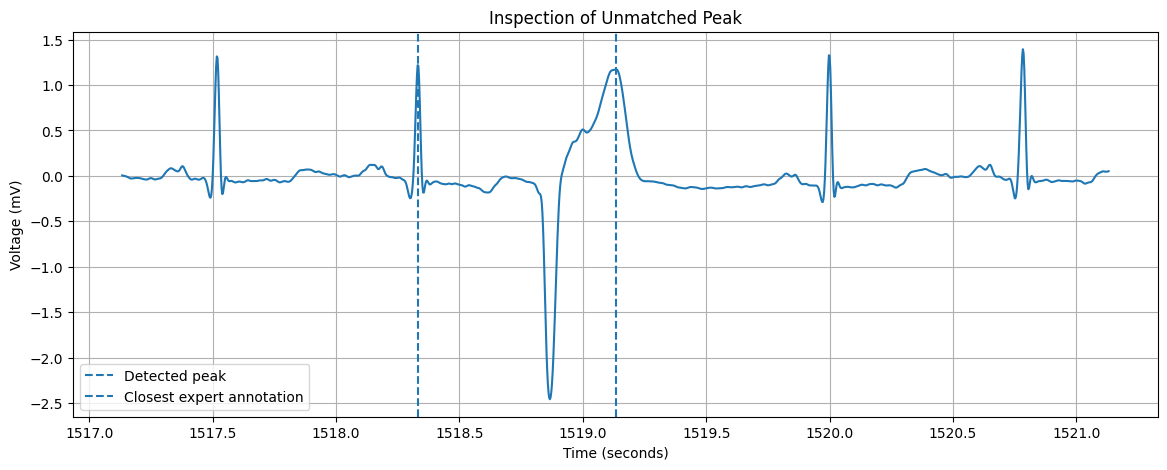

In [ ]:
# Plot around the unmatched peak
peak = 546888

window = int(2 * fs)  # 2 seconds on each side

start = peak - window
end = peak + window

plt.figure(figsize=(14, 5))

plt.plot(
    time[start:end],
    ecg_filtered[start:end]
)

# Mark the detected peak
plt.axvline(
    time[peak],
    linestyle='--',
    label='Detected peak'
)

# Mark the closest expert annotation
closest_annotation = 546599

plt.axvline(
    time[closest_annotation],
    linestyle='--',
    label='Closest expert annotation'
)

plt.title("Inspection of Unmatched Peak")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
target = 546888

# Look at ALL expert annotations within ±2 seconds
window = int(2 * fs)

nearby = np.where(
    np.abs(annotation.sample - target) <= window
)[0]

print("All expert annotations near the unmatched peak:\n")

for i in nearby:
    sample = annotation.sample[i]
    symbol = annotation.symbol[i]

    print(
        f"Sample: {sample:6d} | "
        f"Time: {sample/fs:.4f} s | "
        f"Label: {symbol}"
    )

All expert annotations near the unmatched peak:

Sample: 546306 | Time: 1517.5167 s | Label: N
Sample: 546599 | Time: 1518.3306 s | Label: N
Sample: 546792 | Time: 1518.8667 s | Label: V
Sample: 547199 | Time: 1519.9972 s | Label: N
Sample: 547482 | Time: 1520.7833 s | Label: N


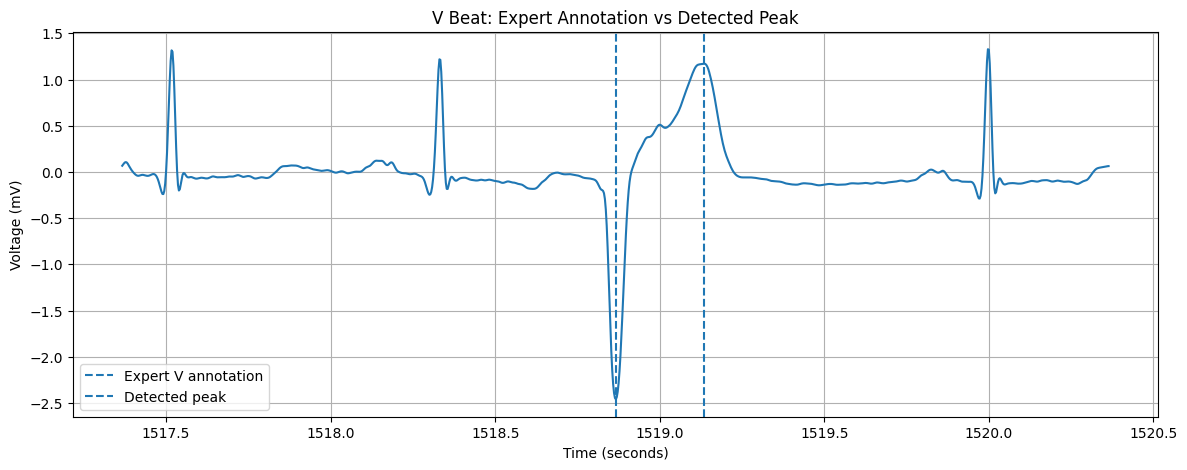

In [ ]:
v_sample = 546792

window = int(1.5 * fs)

start = v_sample - window
end = v_sample + window

plt.figure(figsize=(14, 5))

plt.plot(
    time[start:end],
    ecg_filtered[start:end]
)

# Expert V annotation
plt.axvline(
    time[v_sample],
    linestyle='--',
    label='Expert V annotation'
)

# Our detected peak
plt.axvline(
    time[546888],
    linestyle='--',
    label='Detected peak'
)

plt.title("V Beat: Expert Annotation vs Detected Peak")
plt.xlabel("Time (seconds)")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from collections import Counter

selected_labels = [
    symbol for symbol in annotation.symbol
    if symbol in ['N', 'A', 'V']
]

print(Counter(selected_labels))

Counter({'N': 2239, 'A': 33, 'V': 1})


In [ ]:
# Select the beat classes we want
selected_classes = ['N', 'A', 'V']

selected_samples = []
selected_labels = []

for sample, symbol in zip(annotation.sample, annotation.symbol):
    if symbol in selected_classes:
        selected_samples.append(sample)
        selected_labels.append(symbol)

selected_samples = np.array(selected_samples)
selected_labels = np.array(selected_labels)

print("Total selected beats:", len(selected_samples))
print("Class counts:", Counter(selected_labels))

Total selected beats: 2273
Class counts: Counter({np.str_('N'): 2239, np.str_('A'): 33, np.str_('V'): 1})


In [ ]:
before = int(0.2 * fs)
after = int(0.4 * fs)

expert_beats = []
expert_labels = []

for sample, label in zip(selected_samples, selected_labels):

    start = sample - before
    end = sample + after

    # Skip annotations too close to the beginning/end
    if start < 0 or end > len(ecg_filtered):
        continue

    beat = ecg_filtered[start:end]

    # Make sure every beat has exactly 216 samples
    if len(beat) == before + after:
        expert_beats.append(beat)
        expert_labels.append(label)

expert_beats = np.array(expert_beats)
expert_labels = np.array(expert_labels)

print("Dataset shape:", expert_beats.shape)
print("Labels shape:", expert_labels.shape)
print("Class counts:", Counter(expert_labels))

Dataset shape: (2272, 216)
Labels shape: (2272,)
Class counts: Counter({np.str_('N'): 2238, np.str_('A'): 33, np.str_('V'): 1})


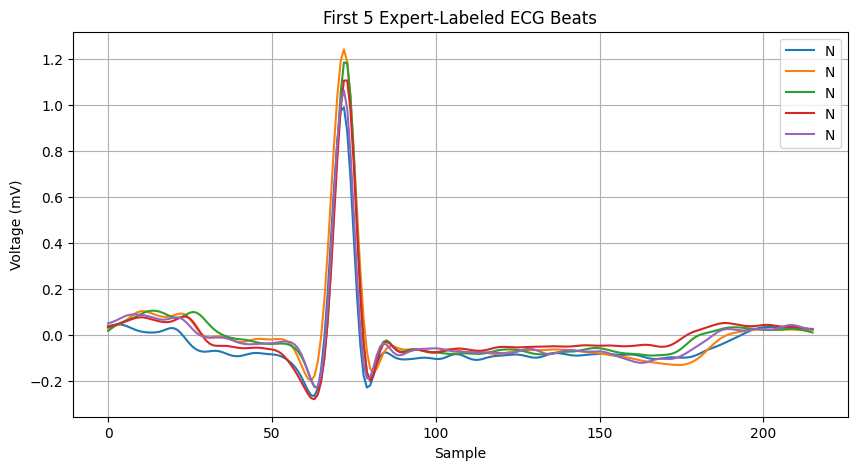

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(5):
    plt.plot(expert_beats[i], label=expert_labels[i])

plt.title("First 5 Expert-Labeled ECG Beats")
plt.xlabel("Sample")
plt.ylabel("Voltage (mV)")
plt.legend()
plt.grid(True)

plt.show()

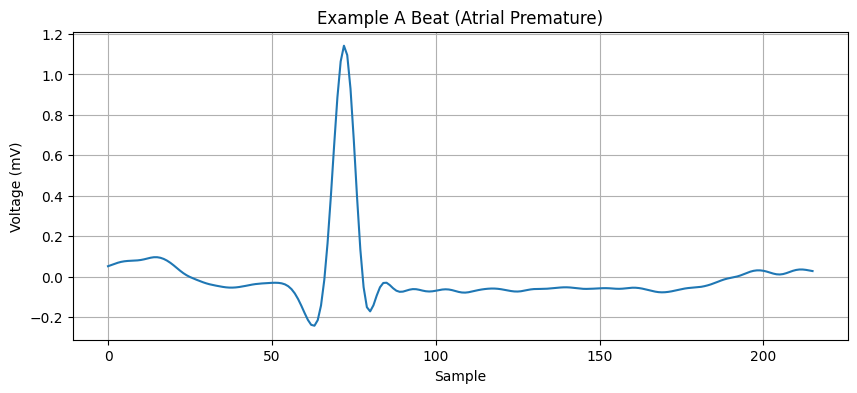

In [ ]:
a_index = np.where(expert_labels == 'A')[0][0]

plt.figure(figsize=(10, 4))

plt.plot(expert_beats[a_index])

plt.title("Example A Beat (Atrial Premature)")
plt.xlabel("Sample")
plt.ylabel("Voltage (mV)")
plt.grid(True)

plt.show()

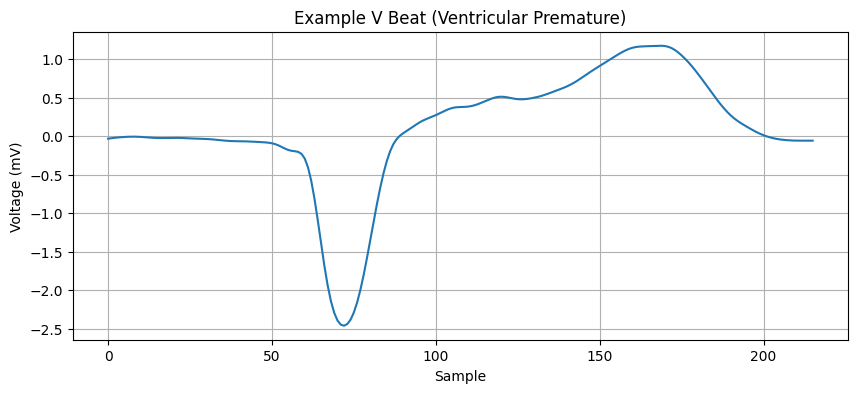

In [ ]:
v_index = np.where(expert_labels == 'V')[0][0]

plt.figure(figsize=(10, 4))

plt.plot(expert_beats[v_index])

plt.title("Example V Beat (Ventricular Premature)")
plt.xlabel("Sample")
plt.ylabel("Voltage (mV)")
plt.grid(True)

plt.show()

**Visualizing Extracted Beats**

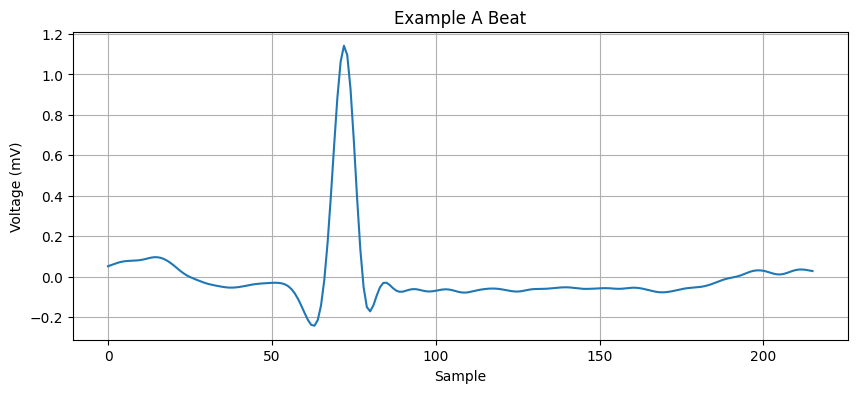

In [ ]:
# Find the first A beat and the V beat
a_index = np.where(expert_labels == 'A')[0][0]
v_index = np.where(expert_labels == 'V')[0][0]

# Plot A beat
plt.figure(figsize=(10, 4))
plt.plot(expert_beats[a_index])

plt.title("Example A Beat")
plt.xlabel("Sample")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

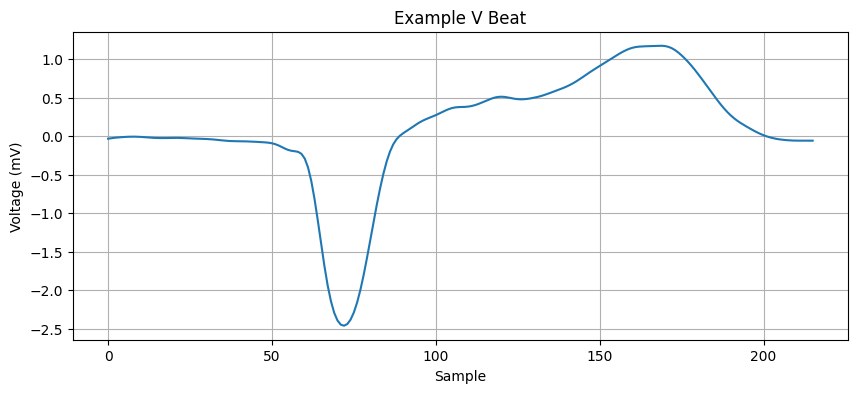

In [ ]:
# Plot V beat
plt.figure(figsize=(10, 4))
plt.plot(expert_beats[v_index])

plt.title("Example V Beat")
plt.xlabel("Sample")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

**Load multiple MIT-BIH records**

In [ ]:
import wfdb
from collections import Counter

records = [
    '100', '101', '102', '103', '104', '105', '106', '107',
    '108', '109', '111', '112', '113', '114', '115', '116',
    '117', '118', '119', '121', '122', '123', '124',
    '200', '201', '202', '203', '205', '207', '208', '209',
    '210', '212', '213', '214', '215', '217', '219', '220',
    '221', '222', '223', '228', '230', '231', '232', '233',
    '234'
]

results = []

for record_name in records:

    annotation = wfdb.rdann(
        record_name,
        'atr',
        pn_dir='mitdb'
    )

    counts = Counter(annotation.symbol)

    results.append({
        'Record': record_name,
        'N': counts.get('N', 0),
        'A': counts.get('A', 0),
        'V': counts.get('V', 0)
    })

for result in results:
    print(
        f"Record {result['Record']}: "
        f"N={result['N']}, "
        f"A={result['A']}, "
        f"V={result['V']}"
    )

Record 100: N=2239, A=33, V=1
Record 101: N=1860, A=3, V=0
Record 102: N=99, A=0, V=4
Record 103: N=2082, A=2, V=0
Record 104: N=163, A=0, V=2
Record 105: N=2526, A=0, V=41
Record 106: N=1507, A=0, V=520
Record 107: N=0, A=0, V=59
Record 108: N=1739, A=4, V=17
Record 109: N=0, A=0, V=38
Record 111: N=0, A=0, V=1
Record 112: N=2537, A=2, V=0
Record 113: N=1789, A=0, V=0
Record 114: N=1820, A=10, V=43
Record 115: N=1953, A=0, V=0
Record 116: N=2302, A=1, V=109
Record 117: N=1534, A=1, V=0
Record 118: N=0, A=96, V=16
Record 119: N=1543, A=0, V=444
Record 121: N=1861, A=1, V=1
Record 122: N=2476, A=0, V=0
Record 123: N=1515, A=0, V=3
Record 124: N=0, A=2, V=47
Record 200: N=1743, A=30, V=826
Record 201: N=1625, A=30, V=198
Record 202: N=2061, A=36, V=19
Record 203: N=2529, A=0, V=444
Record 205: N=2571, A=3, V=71
Record 207: N=0, A=107, V=105
Record 208: N=1586, A=0, V=992
Record 209: N=2621, A=383, V=1
Record 210: N=2423, A=0, V=194
Record 212: N=923, A=0, V=0
Record 213: N=2641, A=25, V=

In [ ]:
import wfdb
import numpy as np
from scipy.signal import butter, filtfilt
from collections import Counter


def process_record(record_name):

    # -----------------------------
    # 1. Load ECG signal
    # -----------------------------
    record = wfdb.rdrecord(record_name, pn_dir='mitdb')

    # Use first ECG channel
    ecg = record.p_signal[:, 0]

    # Sampling frequency
    fs = record.fs

    # -----------------------------
    # 2. Filter ECG
    # -----------------------------
    lowcut = 0.5
    highcut = 40.0

    b, a = butter(
        4,
        [lowcut / (fs / 2),
         highcut / (fs / 2)],
        btype='band'
    )

    ecg_filtered = filtfilt(b, a, ecg)

    # -----------------------------
    # 3. Load expert annotations
    # -----------------------------
    annotation = wfdb.rdann(
        record_name,
        'atr',
        pn_dir='mitdb'
    )

    # -----------------------------
    # 4. Select N, A and V
    # -----------------------------
    selected_classes = ['N', 'A', 'V']

    samples = []
    labels = []

    for sample, symbol in zip(
        annotation.sample,
        annotation.symbol
    ):

        if symbol in selected_classes:
            samples.append(sample)
            labels.append(symbol)

    samples = np.array(samples)
    labels = np.array(labels)

    # -----------------------------
    # 5. Beat segmentation
    # -----------------------------
    before = int(0.2 * fs)
    after = int(0.4 * fs)

    beats = []
    beat_labels = []

    for sample, label in zip(samples, labels):

        start = sample - before
        end = sample + after

        # Ignore beats too close to boundaries
        if start < 0 or end > len(ecg_filtered):
            continue

        beat = ecg_filtered[start:end]

        # Make sure every beat has 216 samples
        if len(beat) == before + after:
            beats.append(beat)
            beat_labels.append(label)

    beats = np.array(beats)
    beat_labels = np.array(beat_labels)

    # -----------------------------
    # 6. Return results
    # -----------------------------
    return beats, beat_labels

In [ ]:
beats_106, labels_106 = process_record('106')

print("Shape of beats:", beats_106.shape)
print("Shape of labels:", labels_106.shape)
print("Class counts:", Counter(labels_106))

Shape of beats: (2027, 216)
Shape of labels: (2027,)
Class counts: Counter({np.str_('N'): 1507, np.str_('V'): 520})


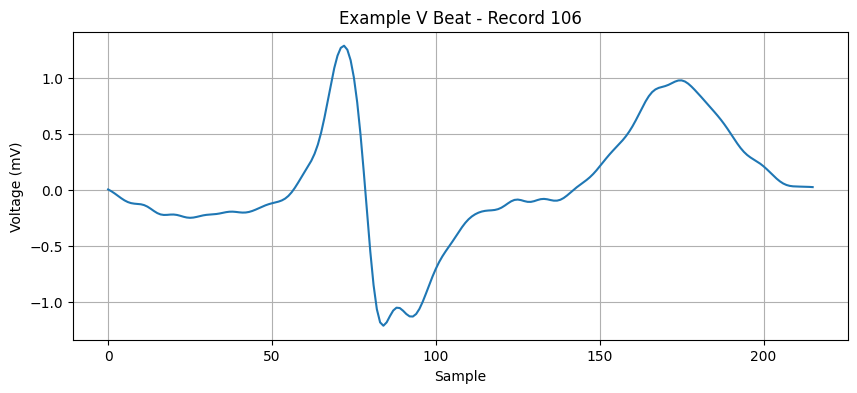

In [ ]:
v_index = np.where(labels_106 == 'V')[0][0]

plt.figure(figsize=(10, 4))

plt.plot(beats_106[v_index])

plt.title("Example V Beat - Record 106")
plt.xlabel("Sample")
plt.ylabel("Voltage (mV)")
plt.grid(True)

plt.show()

In [ ]:
train_records = [
    '100',
    '106',
    '114',
    '116',
    '119',
    '201',
    '205',
    '223',
    '228',
    '233'
]

val_records = [
    '202',
    '213'
]

test_records = [
    '200',
    '219'
]

print("Training records:", train_records)
print("Validation records:", val_records)
print("Test records:", test_records)

Training records: ['100', '106', '114', '116', '119', '201', '205', '223', '228', '233']
Validation records: ['202', '213']
Test records: ['200', '219']


In [ ]:
train_beats_list = []
train_labels_list = []

for record_name in train_records:

    print("Processing record:", record_name)

    beats, labels = process_record(record_name)

    train_beats_list.append(beats)
    train_labels_list.append(labels)

    print("  Beats:", beats.shape[0])
    print("  Classes:", Counter(labels))


# Combine all training records
X_train = np.concatenate(train_beats_list, axis=0)
y_train = np.concatenate(train_labels_list, axis=0)

print("\nFinal training dataset:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Class distribution:", Counter(y_train))

Processing record: 100
  Beats: 2272
  Classes: Counter({np.str_('N'): 2238, np.str_('A'): 33, np.str_('V'): 1})
Processing record: 106
  Beats: 2027
  Classes: Counter({np.str_('N'): 1507, np.str_('V'): 520})
Processing record: 114
  Beats: 1873
  Classes: Counter({np.str_('N'): 1820, np.str_('V'): 43, np.str_('A'): 10})
Processing record: 116
  Beats: 2411
  Classes: Counter({np.str_('N'): 2301, np.str_('V'): 109, np.str_('A'): 1})
Processing record: 119
  Beats: 1987
  Classes: Counter({np.str_('N'): 1543, np.str_('V'): 444})
Processing record: 201
  Beats: 1853
  Classes: Counter({np.str_('N'): 1625, np.str_('V'): 198, np.str_('A'): 30})
Processing record: 205
  Beats: 2644
  Classes: Counter({np.str_('N'): 2570, np.str_('V'): 71, np.str_('A'): 3})
Processing record: 223
  Beats: 2574
  Classes: Counter({np.str_('N'): 2029, np.str_('V'): 473, np.str_('A'): 72})
Processing record: 228
  Beats: 2053
  Classes: Counter({np.str_('N'): 1688, np.str_('V'): 362, np.str_('A'): 3})
Processi

**Validation Dataset**

In [ ]:
val_beats_list = []
val_labels_list = []

for record_name in val_records:

    print("Processing validation record:", record_name)

    beats, labels = process_record(record_name)

    val_beats_list.append(beats)
    val_labels_list.append(labels)

    print("  Beats:", beats.shape[0])
    print("  Classes:", Counter(labels))


X_val = np.concatenate(val_beats_list, axis=0)
y_val = np.concatenate(val_labels_list, axis=0)

print("\nFinal validation dataset:")
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("Class distribution:", Counter(y_val))

Processing validation record: 202
  Beats: 2115
  Classes: Counter({np.str_('N'): 2060, np.str_('A'): 36, np.str_('V'): 19})
Processing validation record: 213
  Beats: 2885
  Classes: Counter({np.str_('N'): 2640, np.str_('V'): 220, np.str_('A'): 25})

Final validation dataset:
X_val shape: (5000, 216)
y_val shape: (5000,)
Class distribution: Counter({np.str_('N'): 4700, np.str_('V'): 239, np.str_('A'): 61})


**Test Dataset**

In [ ]:
test_beats_list = []
test_labels_list = []

for record_name in test_records:

    print("Processing test record:", record_name)

    beats, labels = process_record(record_name)

    test_beats_list.append(beats)
    test_labels_list.append(labels)

    print("  Beats:", beats.shape[0])
    print("  Classes:", Counter(labels))


X_test = np.concatenate(test_beats_list, axis=0)
y_test = np.concatenate(test_labels_list, axis=0)

print("\nFinal test dataset:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("Class distribution:", Counter(y_test))

Processing test record: 200
  Beats: 2598
  Classes: Counter({np.str_('N'): 1742, np.str_('V'): 826, np.str_('A'): 30})
Processing test record: 219
  Beats: 2153
  Classes: Counter({np.str_('N'): 2082, np.str_('V'): 64, np.str_('A'): 7})

Final test dataset:
X_test shape: (4751, 216)
y_test shape: (4751,)
Class distribution: Counter({np.str_('N'): 3824, np.str_('V'): 890, np.str_('A'): 37})


In [ ]:
label_map = {
    'N': 0,
    'A': 1,
    'V': 2
}

y_train_encoded = np.array([
    label_map[label] for label in y_train
])

y_val_encoded = np.array([
    label_map[label] for label in y_val
])

y_test_encoded = np.array([
    label_map[label] for label in y_test
])

print("Training labels:", Counter(y_train_encoded))
print("Validation labels:", Counter(y_val_encoded))
print("Test labels:", Counter(y_test_encoded))

Training labels: Counter({np.int64(0): 19550, np.int64(2): 3051, np.int64(1): 159})
Validation labels: Counter({np.int64(0): 4700, np.int64(2): 239, np.int64(1): 61})
Test labels: Counter({np.int64(0): 3824, np.int64(2): 890, np.int64(1): 37})


**Normalization**

In [ ]:
def normalize_beats(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)

    # Avoid division by zero
    std[std == 0] = 1

    return (X - mean) / std


X_train_norm = normalize_beats(X_train)
X_val_norm = normalize_beats(X_val)
X_test_norm = normalize_beats(X_test)

print("Training:", X_train_norm.shape)
print("Validation:", X_val_norm.shape)
print("Test:", X_test_norm.shape)

Training: (22760, 216)
Validation: (5000, 216)
Test: (4751, 216)


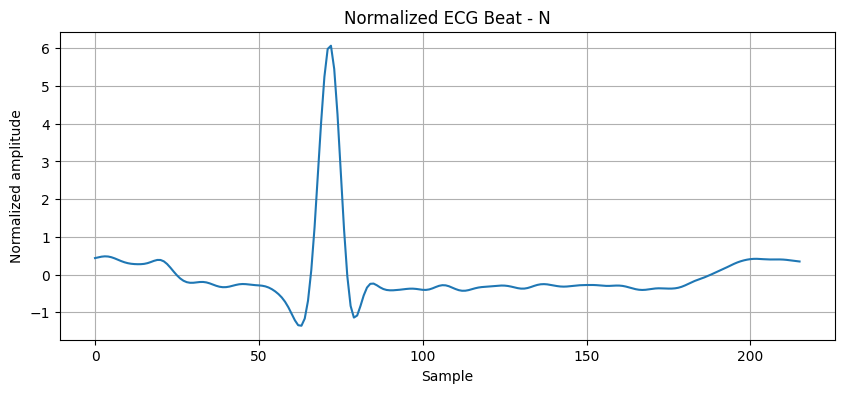

In [ ]:
plt.figure(figsize=(10, 4))

plt.plot(X_train_norm[0])

plt.title("Normalized ECG Beat - N")
plt.xlabel("Sample")
plt.ylabel("Normalized amplitude")
plt.grid(True)

plt.show()

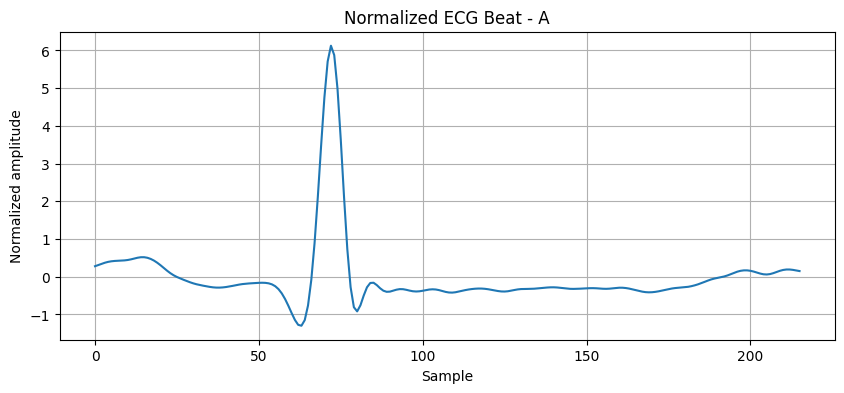

In [ ]:
a_index = np.where(y_train_encoded == 1)[0][0]

plt.figure(figsize=(10, 4))

plt.plot(X_train_norm[a_index])

plt.title("Normalized ECG Beat - A")
plt.xlabel("Sample")
plt.ylabel("Normalized amplitude")
plt.grid(True)

plt.show()

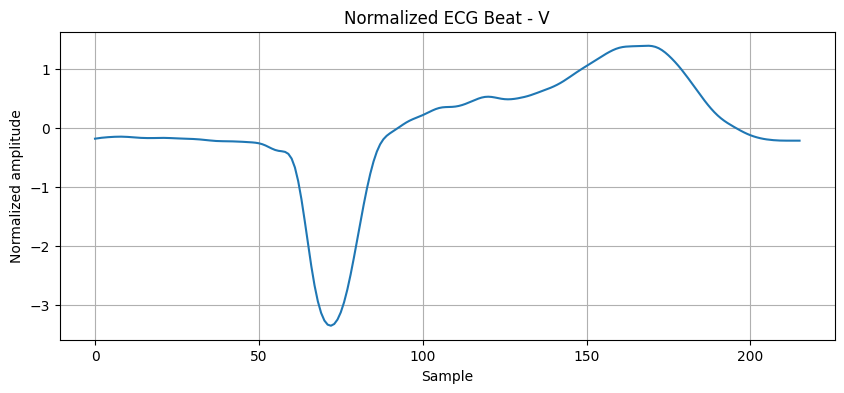

In [ ]:
v_index = np.where(y_train_encoded == 2)[0][0]

plt.figure(figsize=(10, 4))

plt.plot(X_train_norm[v_index])

plt.title("Normalized ECG Beat - V")
plt.xlabel("Sample")
plt.ylabel("Normalized amplitude")
plt.grid(True)

plt.show()

**Calculating Class Weights**

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_encoded)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_encoded
)

class_weights = dict(
    zip(classes, class_weights_array)
)

print("Class weights:")

for class_id, weight in class_weights.items():
    print(
        f"Class {class_id}: {weight:.3f}"
    )

Class weights:
Class 0: 0.388
Class 1: 47.715
Class 2: 2.487


**Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created.")

Random Forest model created.


In [ ]:
rf_model.fit(
    X_train_norm,
    y_train_encoded
)

print("Training completed!")

Training completed!


**Testing on Validation data**

In [ ]:
y_val_pred = rf_model.predict(X_val_norm)

print("Validation predictions completed!")
print("Number of predictions:", len(y_val_pred))

Validation predictions completed!
Number of predictions: 5000


**Validation Accuracy**

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_val_encoded,
    y_val_pred
)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.9846


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_val_encoded,
    y_val_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4694    3    3]
 [  61    0    0]
 [  10    0  229]]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val_encoded,
        y_val_pred,
        target_names=['N', 'A', 'V'],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           N       0.99      1.00      0.99      4700
           A       0.00      0.00      0.00        61
           V       0.99      0.96      0.97       239

    accuracy                           0.98      5000
   macro avg       0.66      0.65      0.65      5000
weighted avg       0.97      0.98      0.98      5000



**1D CNN**

In [ ]:
X_train_cnn = X_train_norm[..., np.newaxis]
X_val_cnn = X_val_norm[..., np.newaxis]
X_test_cnn = X_test_norm[..., np.newaxis]

print("Training CNN input:", X_train_cnn.shape)
print("Validation CNN input:", X_val_cnn.shape)
print("Test CNN input:", X_test_cnn.shape)

Training CNN input: (22760, 216, 1)
Validation CNN input: (5000, 216, 1)
Test CNN input: (4751, 216, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

cnn_model = Sequential([

    # First convolution block
    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu',
        input_shape=(216, 1)
    ),

    BatchNormalization(),

    MaxPooling1D(
        pool_size=2
    ),

    # Second convolution block
    Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling1D(
        pool_size=2
    ),

    # Convert feature maps to a vector
    Flatten(),

    # Fully connected layer
    Dense(
        64,
        activation='relu'
    ),

    # Reduce overfitting
    Dropout(0.5),

    # Output: N, A, V
    Dense(
        3,
        activation='softmax'
    )
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 212, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 212, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 106, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 102, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 102, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 51, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3264)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       208,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,035 (859.51 KB)

 Trainable params: 219,843 (858.76 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN compiled successfully!")

CNN compiled successfully!


In [ ]:
history = cnn_model.fit(
    X_train_cnn,
    y_train_encoded,
    validation_data=(X_val_cnn, y_val_encoded),
    epochs=15,
    batch_size=64,
    class_weight=class_weights
)

Epoch 1/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - accuracy: 0.6834 - loss: 0.7734 - val_accuracy: 0.6932 - val_loss: 0.6410
Epoch 2/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.7103 - loss: 0.5053 - val_accuracy: 0.2254 - val_loss: 1.6456
Epoch 3/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.6788 - loss: 0.4599 - val_accuracy: 0.7464 - val_loss: 0.4727
Epoch 4/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.7167 - loss: 0.4095 - val_accuracy: 0.7594 - val_loss: 0.4929
Epoch 5/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.7514 - loss: 0.3736 - val_accuracy: 0.7440 - val_loss: 0.5093
Epoch 6/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.7502 - loss: 0.4137 - val_accuracy: 0.7714 - val_loss: 0.4310
Epoch 7/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.7976 - loss: 0.3314 - val_accuracy: 0.8110 - val_loss: 0.4118
Epoch 8/15
356/356 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.8274 - loss: 0.2750 - 

In [ ]:
y_val_cnn_prob = cnn_model.predict(X_val_cnn)

y_val_cnn_pred = np.argmax(
    y_val_cnn_prob,
    axis=1
)

print("CNN validation predictions completed.")
print("Number of predictions:", len(y_val_cnn_pred))

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
CNN validation predictions completed.
Number of predictions: 5000


In [ ]:
from sklearn.metrics import confusion_matrix

cm_cnn = confusion_matrix(
    y_val_encoded,
    y_val_cnn_pred
)

print("CNN Confusion Matrix:")
print(cm_cnn)

CNN Confusion Matrix:
[[4193  365  142]
 [  40   20    1]
 [   3    0  236]]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val_encoded,
        y_val_cnn_pred,
        target_names=['N', 'A', 'V'],
        zero_division=0
    )
)

              precision    recall  f1-score   support

           N       0.99      0.89      0.94      4700
           A       0.05      0.33      0.09        61
           V       0.62      0.99      0.76       239

    accuracy                           0.89      5000
   macro avg       0.55      0.74      0.60      5000
weighted avg       0.96      0.89      0.92      5000



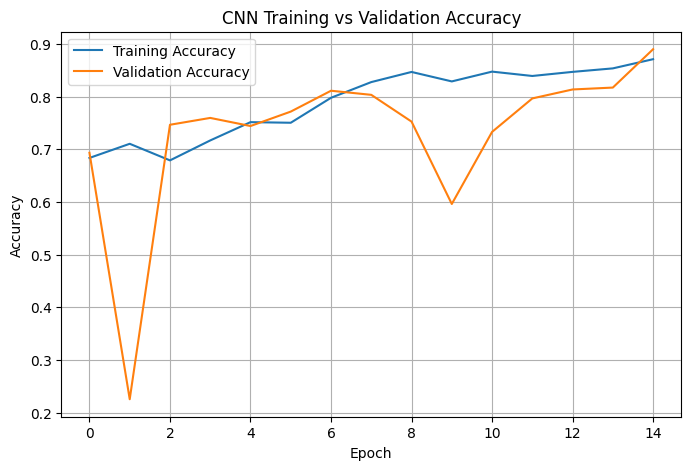

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.show()

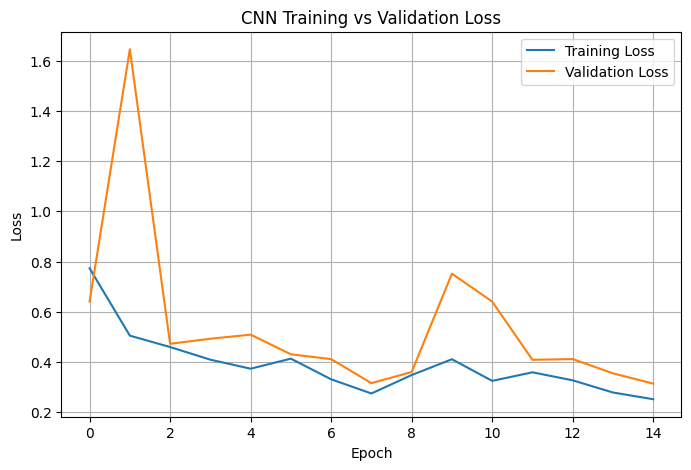

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

cnn_model = Sequential([

    Input(shape=(216, 1)),

    Conv1D(
        filters=32,
        kernel_size=5,
        activation='relu'
    ),

    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=5,
        activation='relu'
    ),

    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(3, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 212, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 212, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 106, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 102, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 102, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 51, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3264)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       208,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,035 (859.51 KB)

 Trainable params: 219,843 (858.76 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    'best_cnn_model.keras',
    monitor='val_loss',
    save_best_only=True
)

In [ ]:
history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_encoded,
    validation_data=(X_val_cnn, y_val_encoded),
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.8528 - loss: 0.3019 - val_accuracy: 0.6752 - val_loss: 0.5828 - learning_rate: 2.5000e-04
Epoch 2/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.8627 - loss: 0.2462 - val_accuracy: 0.7570 - val_loss: 0.4042 - learning_rate: 2.5000e-04
Epoch 3/20
356/356 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.8936 - loss: 0.2271 - val_accuracy: 0.6932 - val_loss: 0.4979 - learning_rate: 1.2500e-04
